In [58]:
!pip install torch matplotlib

  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)

[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [34]:
M=20  #size of the truncated master field
K= 2*M  #number of loop equations we are imposing
g=0  #coupling


# parameters for gradient descent 
learning_rate = 0.1
num_epochs = 1000

# loss function : sum of squares of loop equations
def loss(phi_pos, g, M, K):
    phi = torch.cat([-phi_pos, phi_pos])
    w = [torch.sum(phi**n) / M for n in range(0, K+3)]
    residuals = []
    for n in range(2, K+1, 2):
        Ln = w[n] +4 * g * w[n+2] - sum(w[k] * w[n-2-k] for k in range(0, n-1))
        rn = (1/4)**n
        residuals.append(rn*Ln**2)
    return sum(residuals)

# regularized master field
phi_pos = torch.rand(M//2).double() 
phi_pos.requires_grad_(True)

optim = torch.optim.Adam([phi_pos], lr=learning_rate)

for epoch in range(num_epochs):
    optim.zero_grad()
    L=loss(phi_pos,g,M,K)
    L.backward()
    optim.step()
    if epoch % 100 == 0:
        print(f"epoch {epoch}, loss {L.item():.6f}")

        
phi = torch.cat([-phi_pos, phi_pos])
print(phi.detach().numpy())

w = [torch.sum(phi**n) / M for n in range(0, K+3)]
print(w[2].item())
print(w[4].item())
print(w[6].item())
    

epoch 0, loss 0.035696
epoch 100, loss 0.000025
epoch 200, loss 0.000017
epoch 300, loss 0.000016
epoch 400, loss 0.000015
epoch 500, loss 0.000015
epoch 600, loss 0.000015
epoch 700, loss 0.000015
epoch 800, loss 0.000015
epoch 900, loss 0.000015
[-0.73390323 -1.27829893 -0.0914937  -0.33481345 -0.49883514 -1.27638489
 -1.27598797 -1.81448681 -0.93980518  0.13028219  0.73390323  1.27829893
  0.0914937   0.33481345  0.49883514  1.27638489  1.27598797  1.81448681
  0.93980518 -0.13028219]
0.9991843055232412
1.995982875051063
4.955326200193899


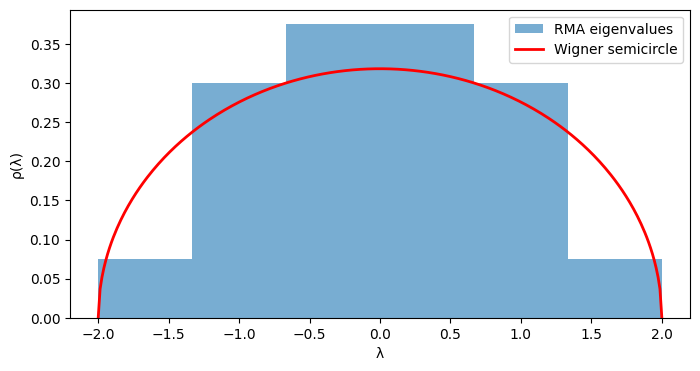

histogram area = 1.000000
semicircle area = 0.999795


In [31]:
phi_vals = np.sort(phi.detach().numpy())
lam = np.linspace(-2, 2, 300)
rho_exact = np.sqrt(np.maximum(4 - lam**2, 0)) / (2 * np.pi)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(phi_vals, bins=np.linspace(-2, 2, 7), 
        density=True, alpha=0.6, label='RMA eigenvalues')
ax.plot(lam, rho_exact, 'r-', lw=2, label='Wigner semicircle')
ax.set_xlabel('λ')
ax.set_ylabel('ρ(λ)')
ax.legend()
plt.show()

# sanity check: print the area of the histogram
counts, bin_edges = np.histogram(phi_vals, bins=np.linspace(-2, 2, 11), density=True)
print(f"histogram area = {np.sum(counts * np.diff(bin_edges)):.6f}")  # should be 1.0
print(f"semicircle area = {np.trapezoid(rho_exact, lam):.6f}")           # should be 1.0

In [42]:
from math import factorial
import numpy as np

def exact_moments_phi4(g, n_max):
    if g == 0:
        return [comb(2*n, n) / (n+1) for n in range(n_max+1)]
    
    a2 = (np.sqrt(1 + 48*g) - 1) / (6*g)
    
    moments = []
    for n in range(n_max+1):
        coeff = factorial(2*n) / (factorial(n) * factorial(n+2))
        w = coeff * (a2/4)**n * (2*(n+1) - n*a2/4)
        moments.append(w)
    return moments

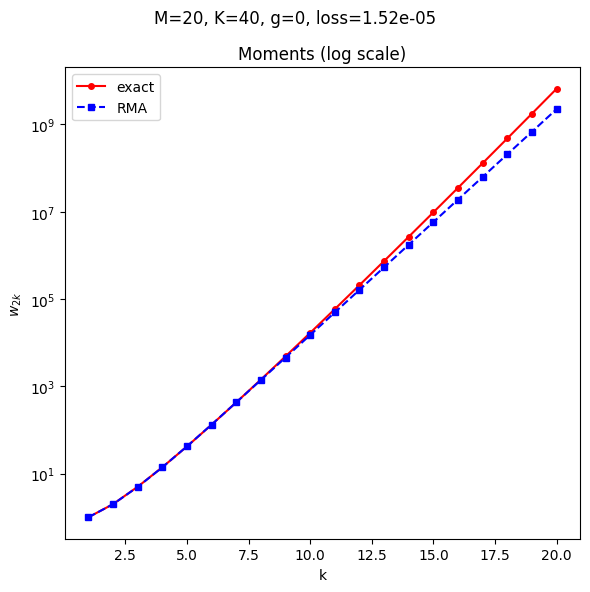

In [40]:
# recompute moments after training
with torch.no_grad():
    phi = torch.cat([-phi_pos, phi_pos])
    w = [torch.sum(phi**n) / M for n in range(0, K+3)]

ns = range(1, K//2 + 1)  # k index: t_{2k}
w_numerical = [w[2*k].item() for k in ns]
w_exact     = [catalan(k) for k in ns]


fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# left: absolute values on log scale
axes.semilogy(list(ns), w_exact, 'r-o', markersize=4, label='exact')
axes.semilogy(list(ns), w_numerical, 'b--s', markersize=4, label='RMA')
axes.set_xlabel('k')
axes.set_ylabel('$w_{2k}$')
axes.set_title('Moments (log scale)')
axes.legend()


plt.suptitle(f'M={M}, K={K}, g={g}, loss={L.item():.2e}')
plt.tight_layout()
plt.show()

Starting gradient descent: M=16, K=48, g=1, lr=0.01, epochs=500
  epoch 0/500, loss 1.225447e-01
  epoch 200/500, loss 1.398004e-03
  epoch 400/500, loss 1.266201e-03
Done. Final loss: 1.257096e-03

Starting gradient descent: M=32, K=96, g=1, lr=0.01, epochs=500
  epoch 0/500, loss 1.409530e-01
  epoch 200/500, loss 3.138272e-04
  epoch 400/500, loss 3.098638e-04
Done. Final loss: 3.083157e-04

Starting gradient descent: M=64, K=192, g=1, lr=0.01, epochs=500
  epoch 0/500, loss 2.176231e-02
  epoch 200/500, loss 7.558548e-05
  epoch 400/500, loss 7.102065e-05
Done. Final loss: 7.053266e-05



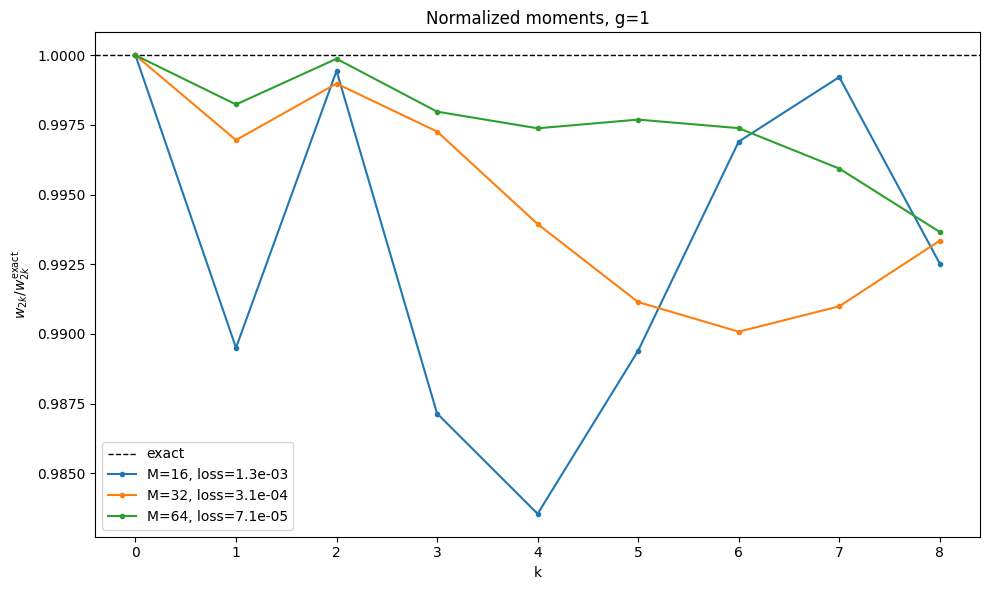

In [45]:
# loss function : sum of squares of loop equations
def loss(phi_pos, g, M, K):
    phi = torch.cat([-phi_pos, phi_pos])
    w = [torch.sum(phi**n) / M for n in range(0, K+3)]
    residuals = []
    for n in range(2, K+1, 2):
        Ln = w[n] +4 * g * w[n+2] - sum(w[k] * w[n-2-k] for k in range(0, n-1))
        a2 = (np.sqrt(1 + 48*g) - 1) / (6*g)
        rn = (1/a2)**n
        residuals.append(rn*Ln**2)
    return sum(residuals)


# gradient descent over the eigenvalues of the master field
def run_rma(M, K, g, lr=0.01, num_epochs=500):
    print(f"Starting gradient descent: M={M}, K={K}, g={g}, lr={lr}, epochs={num_epochs}")
    
    phi_pos = torch.rand(M//2).double() * 1.0
    phi_pos.requires_grad_(True)
    optim = torch.optim.Adam([phi_pos], lr=lr)
    
    for epoch in range(num_epochs):
        optim.zero_grad()
        L = loss(phi_pos, g, M, K)
        L.backward()
        optim.step()
        if epoch % 200 == 0:
            print(f"  epoch {epoch}/{num_epochs}, loss {L.item():.6e}")
            
    with torch.no_grad():
        phi = torch.cat([-phi_pos, phi_pos])
        w = [torch.sum(phi**n) / M for n in range(0, K+3)]

    print(f"Done. Final loss: {L.item():.6e}\n")
    return w, L.item() #return the moments and the loss

from math import comb,factorial
import numpy as np

def moments_exact(g, n_max):
    if g == 0:
        return [comb(2*n, n) / (n+1) for n in range(n_max+1)]
    a2 = (np.sqrt(1 + 48*g) - 1) / (6*g)
    moments = []
    for n in range(n_max+1):
        coeff = factorial(2*n) / (factorial(n) * factorial(n+2))
        w = coeff * (a2/4)**n * (2*(n+1) - n*a2/4)
        moments.append(w)
    return moments

M_values = [16, 32,64]
g=1


k_max = min(M_values)//2
ks = np.array(range(0, k_max + 1))
w_exact = np.array(moments_exact(g, k_max))

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(1.0, color='k', lw=1, linestyle='--', label='exact')

for M in M_values:
    K = 3 * M
    w, loss_val = run_rma(M, K, g)
    w_num = np.array([w[2*k].item() for k in ks])
    ax.plot(ks, w_num / w_exact, '-o', markersize=3, label=f'M={M}, loss={loss_val:.1e}')

ax.set_xlabel('k')
ax.set_ylabel('$w_{2k} / w_{2k}^\\mathrm{exact}$')
ax.set_title(f'Normalized moments, g={g}')
ax.legend()
plt.tight_layout()
plt.show()
